# **Classification Matrix**

Just like we studied Regression matrix for linear reg, now we will study about Classification matrix for logistic reg.

### Confusion Matrix (Classification Matrix)

A table used to evaluate the performance of a classification model by comparing actual vs. predicted values.

| | Predicted: 0 (Negative) | Predicted: 1 (Positive) |
|:---|:---:|:---:|
| **Actual: 0** | **TN** (True Negative) | **FP** (False Positive - Type I Error) |
| **Actual: 1** | **FN** (False Negative - Type II Error) | **TP** (True Positive) |

**Key Evaluation Metrics:**

1. **Accuracy**: $\frac{TP + TN}{TP + TN + FP + FN}$ (Overall correctness)
2. **Precision**: $\frac{TP}{TP + FP}$ (Reliability of positive predictions)
3. **Recall (Sensitivity)**: $\frac{TP}{TP + FN}$ (Ability to find all positive cases)
4. **F1-Score**: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ (Harmonic mean of Precision and Recall)





In [24]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

In [25]:
df = pd.read_csv('heart.csv')

# Categorical encoding (One-Hot Encoding)
df = pd.get_dummies(df, drop_first=True)

df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [26]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('HeartDisease', axis=1), df['HeartDisease'], test_size=0.2, random_state=2)

# now we will be comparing the predictions of logistic reg and decision tree classifier
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train, y_train)
y_pred1 = clf1.predict(X_test)

clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)

In [ ]:
def print_metrics(y_true, y_pred, model_name):
    print(f"--- {model_name} metrics ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred)}")
    print(f"Precision: {precision_score(y_true, y_pred)}")
    print(f"Recall   : {recall_score(y_true, y_pred)}")
    print(f"F1 Score : {f1_score(y_true, y_pred)}")
    print(f"\nClassification Report : \n{classification_report(y_true, y_pred)}")
    print("\n")

print_metrics(y_test, y_pred1, "Logistic Regression")
print_metrics(y_test, y_pred2, "Decision Tree")


# as you can see logistic reg gives both better accuracy and precision


--- Logistic Regression metrics ---
Accuracy : 0.8369565217391305
Precision: 0.8155339805825242
Recall   : 0.8842105263157894
F1 Score : 0.8484848484848485

Classification Report : 
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        89
           1       0.82      0.88      0.85        95

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



--- Decision Tree metrics ---
Accuracy : 0.7717391304347826
Precision: 0.8117647058823529
Recall   : 0.7263157894736842
F1 Score : 0.7666666666666667

Classification Report : 
              precision    recall  f1-score   support

           0       0.74      0.82      0.78        89
           1       0.81      0.73      0.77        95

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.78      0.77      0.

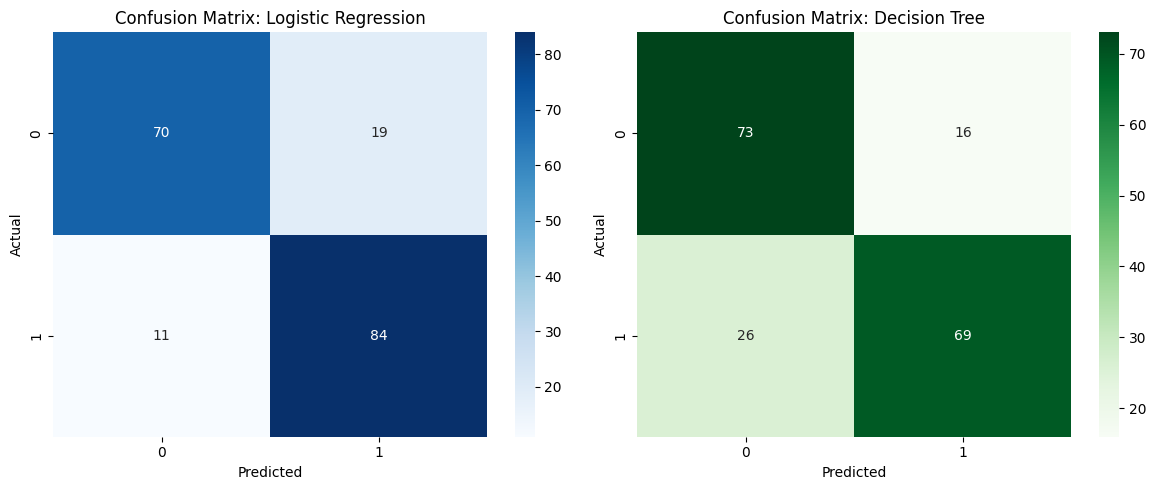

In [28]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred1), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred2), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()